# PROBLEM 2 

 a) 1 pt
 b) 1 pt
 c) 1 pt
 d) 1 pt
 e) 1 pt
 f) 1 pt
 g) 1 pt
 h) 1 pt
 i) 1 pt
 j) 1 pt
 k) 1 pt

__a) Search in the PDB close homologs to the target sequence (see below). What are their names and the corresponding e-values. What are their folds in SCOP?__



- __BLASTP__: To find close homologs --> Using local alignments
- __PSI-BLAST:__ To find distnt-homologs  --> It performs an initial blastp search, builds a custom "profile" (PSSM) from the results, and then uses that profile to search the database again. It repeats this for several iterations.
- __JACKHMMER:__: Very distant homologs --> More sensitive than psi-blast finding the "twilight zone" relatives ($<20\%$ identity) while maintaining better control over false positives.

So for this case, I'll go for blastp to find the closest homolog:
But first I have to create the fasta file. 

```
>target
MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGFIPKNYIRVKPHPW
YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
WEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPGACFAQAQFDFSAQDPSQLSFR
RGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPVHL
```

And now run the blastp:

```
blastp -query target.fa -db /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > target

Length=217
                                                                      Score     E
Sequences producing significant alignments:                          (Bits)  Value

1gri_B mol:protein length:217 GROWTH FACTOR BOUND PROTEIN 2           280     3e-96
1gri_A mol:protein length:217 GROWTH FACTOR BOUND PROTEIN 2           280     3e-96
1bmb_A mol:protein length:123 PROTEIN (GROWTH FACTOR RECEPTOR BOU...  160     2e-50
1bm2_A mol:protein length:117 PROTEIN (GROWTH FACTOR RECEPTOR BOU...  154     4e-48
1fyr_D mol:protein length:114 GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2  151     5e-47
```
The `blastp`search was yielded high-quality results from the provided target sequence. The first two homoloogs `1GRI`have an extremely significant e-value, indicating that tehse are high-confidence homologs. 
Other significant homologs include `1BMB`, `1BM2`, and `1FYR`, all with E-values better than $5 \times 10^{-47}$.

By searching on SCOP, returns a list of representative domains because multi-domain proteins like GRB2 are often classified by their individual structural units rather than a single global entity. 

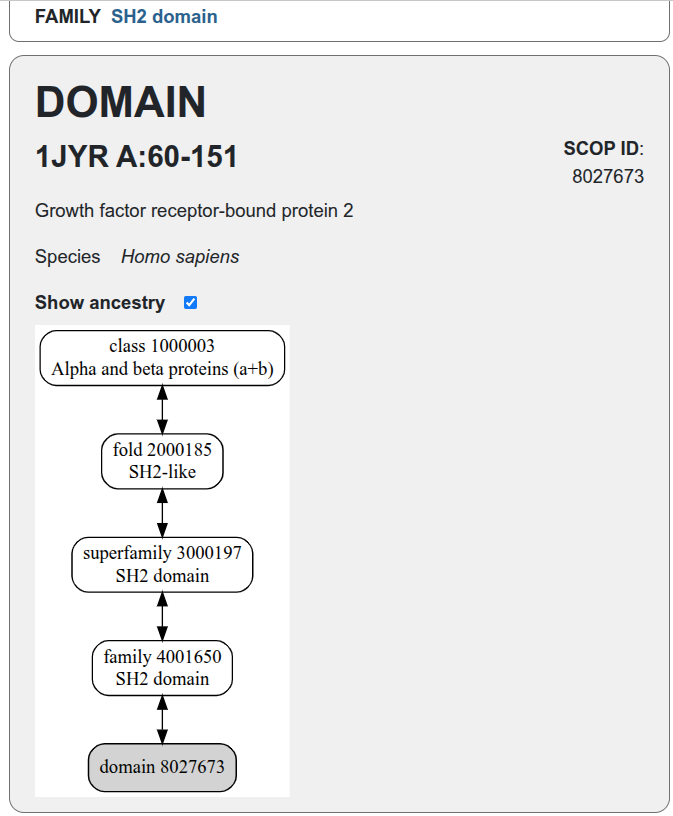

Represents _SH2 domain_, class _alpha+beta_

__b) Superpose the structure of three homologs with DIFFERENT sequence and keep the superposition in a file named p9b.pdb.__

Three different homologs --> 1GRI (chainB), 1GRI (chainA), 1BMB(chainA), 1BM2(chainA), 1FYR(chainD)

_Need to pick three homologs with different sequences. While proteins like 1GRI Chain A and 1GRI Chain B are technically homologs, they have identical sequences and therefore do not count as "different" for this specific task._

1GRI (chainA), 1BMB(chainA), 1FYR(chianD)

```
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/gr/pdb1gri.ent.gz .



__c) Split the target sequence and the templates by domains and superpose the similar domains. Keep the PDB files named p9c_domain1.pdb, p9c_domain2.pdb, p9c_domain3.pdb, etc.__

1. Identify the domain (`hmmscan`)

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm target.fa > targetpfam.out`

```
Query:       target  [L=217]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    1.8e-34  116.7   0.1    2.2e-16   58.8   0.0    2.5  3  SH3_1     SH3 domain
      6e-28   96.0   0.0    1.4e-16   59.5   0.0    2.4  2  SH3_2     Variant SH3 domain
    1.5e-23   82.2   0.2    2.4e-23   81.6   0.2    1.3  1  SH2       SH2 domain
    0.00084   18.8   0.0     0.0026   17.2   0.0    1.8  1  SH3_3     Bacterial SH3 domain
```

It looks for matches to known proteins families for the target.fa and gives yuou the residue coordinates for each domain found in the seq. 

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm 1gri_A.fa > 1gri_A_pfam.out`

```
Query:       1gri_A  [L=211]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    2.1e-31  106.9   0.2    2.5e-16   58.6   0.0    2.7  3  SH3_1     SH3 domain
    3.5e-27   93.5   0.0    5.4e-16   57.7   0.0    2.3  2  SH3_2     Variant SH3 domain
    3.8e-25   87.3   0.0    6.7e-25   86.5   0.0    1.4  1  SH2       SH2 domain
      0.008   15.6   0.1      0.045   13.3   0.1    2.1  2  SH3_3     Bacterial SH3 domain

```

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm 1fyr_D.fa > 1fyr_D_pfam.out`

```
Query:       1fyr_D  [L=95]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    6.3e-26   89.8   0.0    7.7e-26   89.5   0.0    1.1  1  SH2       SH2 domain
```

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm 1bmb_A.fa > 1bmb_A_pfam.out`

```
Query:       1bmb_A  [L=98]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    6.9e-26   89.7   0.0    8.6e-26   89.4   0.0    1.1  1  SH2       SH2 domain

```

From the templates shows, the only one that got the same domaisn as the target is 1gri_A, so will use its domain coordinates:

Domain coordinates from target:
```
>> SH3_1  SH3 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   58.8   0.0   6.5e-20   2.2e-16       1      47 [.       4      49 ..       4      50 .. 0.97
   2 ?   -3.5   0.0       1.8   6.3e+03      31      38 ..      59      66 ..      55      68 .. 0.74
   3 !   55.5   0.0     7e-19   2.4e-15       1      47 [.     164     208 ..     164     209 .. 0.97
>> SH3_2  Variant SH3 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   34.3   0.0   3.2e-12   1.1e-08       5      54 ..       6      55 ..       3      56 .. 0.88
   2 !   59.5   0.0   4.2e-20   1.4e-16       2      55 .]     163     215 ..     162     215 .. 0.93
>> SH2  SH2 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   81.6   0.2   6.9e-27   2.4e-23       1      77 []      60     135 ..      60     135 .. 0.96
```

We wiil choose the ones that have lower ce-value:
Target Sequence Domains:

- Domain 1 (N-terminal SH3): Residues 4 – 49.
- Domain 3 (C-terminal SH3): Residues 163 – 215.
- Domain 2 (Central SH2): Residues 60 – 135.

Domain coordinates from 1gri_A:

```
>> SH3_1  SH3 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   45.7   0.1   8.1e-16   2.8e-12       1      47 [.       4      43 ..       4      44 .. 0.96
   2 ?   -3.0   0.0       1.3   4.4e+03      26      37 ..      48      59 ..      47      62 .. 0.75
   3 !   58.6   0.0   7.3e-20   2.5e-16       1      47 [.     156     200 ..     156     201 .. 0.97
>> SH3_2  Variant SH3 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   33.8   0.0   4.6e-12   1.6e-08       4      53 ..       5      48 ..       2      49 .. 0.92
   2 !   57.7   0.0   1.6e-19   5.4e-16       1      54 [.     154     206 ..     154     207 .. 0.97
>> SH2  SH2 domain
   #    score  bias  c-Evalue  i-Evalue hmmfrom  hmm to    alifrom  ali to    envfrom  env to     acc
 ---   ------ ----- --------- --------- ------- -------    ------- -------    ------- -------    ----
   1 !   86.5   0.0     2e-28   6.7e-25       1      77 []      54     129 ..      54     129 .. 0.96
```

- Domain 1 (N-SH3): Residues 4 – 43.
- Domain 2 (SH2): Residues 54 – 129.
- Domain 3 (C-SH3): Residues 154 – 206.

Now, superpose the templates against each other, using the domain boundaries found in the target as the guide. _Cannot superpose the target yet because unitl now is just a FASTA seq and does not haev a PDB structure. 

Since 1GRI, 1BMB and 1FYR have the same SH2 domain, should superpose all three structures in this file. 

For Domain 2 (The Central SH2):

1. Open 1GRI_A, 1FYR_D, and 1BMB_A.

2. Select the SH2 residues in each (based on your hmmscan output):

   - 1GRI_A: 54-129
   
   - 1FYR_D: 3-78 (check your PDB numbering, usually the whole file)
   
   - 1BMB_A: 5-80

2. Match them: Use MatchMaker or the command line:

   - match #1:1-95 #0:54-129
   - match #2:1-98 #0:54-129

4. Save: p9c_domain2.pdb (Select all three models in the save dialog).

For Domain 1 and 3 (The SH3s):

Since only 1GRI has these, you will likely just save the coordinates for those segments:

1. Select 1GRI_A residues 4-43 -> Save as p9c_domain1.pdb.

2. Select 1GRI_A residues 154-206 -> Save as p9c_domain3.pdb.

To do so, in his case, (see the number of each chian in select > chain), 1gri is #0, 1fyr ios #1 and 1bmb is #2. So on `favorites > command line`, I will type `select #0:54-129 #1:3-78 #2:5-80`. 

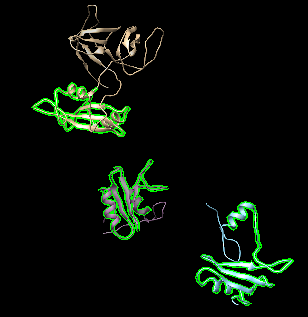

Then, `tools > structure coparison > matcchmaker`pick the reference (1gri_A) and then select the otehr two templates. Click both boxes that sauys `Further restict matching to current selecion`, as this will ensure chimera only to align SH2 domains!. 

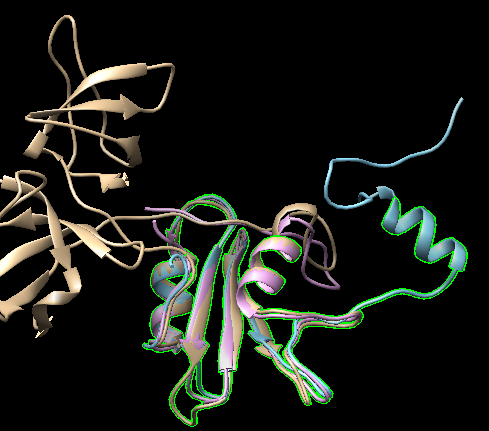

Click `apply` and go to `file > save PDB`. This will ensure all three models are selected and save the file as `p9c_domain2.pdb`.

Because 1BMB and 1FYR do not contain these domains, only be able to superpose them if have mutliple chians of 1GRI.  So `chimera 1gri_A.pdb 1gri_B.pdb`. Paste on the command line `match #0:4-43 #1:4-43` and save the PDB as `p9c_domain1.pdb`. 

Last but not least, do it for the `p9c.domain3.pdb`with this command `match #0:156-200 #1:156-200`.

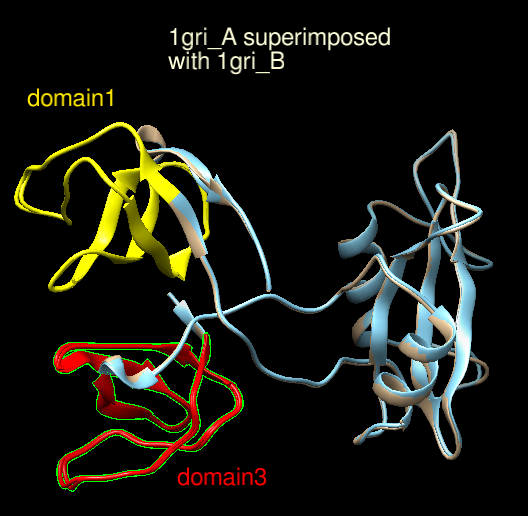

__d) Generate a HMM for the largest sequence with structure using at least three different sequences. Keep the alignment in a text file named  p9d.aln and  p9d.hmm__

Now that we have isolated the domains, the next step is to generate the MSA for the largest sequence. 

```
--- Opening 1gri_A.fa ---
Final character count for 1gri_A.fa: 218
------------------------
--- Opening 1fyr_D.fa ---
Final character count for 1fyr_D.fa: 102
------------------------
--- Opening 1bmb_A.fa ---
Final character count for 1bmb_A.fa: 105
------------------------
```

Since 1gri_A is the largest seq and it contains all three domains, I will use it as my primary template. To build a hmm profile with `hmmbuild` I need an MSA, so will use `clustalw`to align the three templates to create `p9d.aln` and `p9d.hmm` for the hmmbuild. 

```
cat 1gri_A.fa > p9d.fa
cat 1fyr_D.fa >> p9d.fa 
cat 1bmb_A.fa >> p9d.fa 
```
Even though 1fyr_D and 1bmb_A only cover the SH2 region, aligning their full avaiable sequences allows Clustal W to see where hey overlap with the longer 1gri_A.

`clustalw p9d.fa`

```

1gri_A          MEAIAKYDFKATADDELSFKRGDILKVQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIP
1bmb_A          -------------------------------------------------KPHPWFFGKIP
1fyr_D          ---------------------------------------------------HPWFFGKIP
                                                                   *********

1gri_A          RAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFN
1bmb_A          RAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFN
1fyr_D          RAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFN
                ************************************************************

1gri_A          SLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVM
1bmb_A          SLNELVDYHRSTSVSRNQQIFLRDIEQ---------------------------------
1fyr_D          SLNELVDYHRSTSVSRNQQIFLRDIE----------------------------------
                **************************                                  

1gri_A          DNSDPNWWKGACHGQTGMFPRNYVTPVNRNV
1bmb_A          -------------------------------
1fyr_D          -------------------------------
```

When running clustalw it will naturally place gaps at the beggining and end of the shorter sequences. This tells the HMM that these regions are only "known" from 1gri_A while the middle section is supported by all three templates.

`hmmbuild p9d.hmm p9d.aln`

OVERALL: Idenitied 1gri_A acts as the structural "scaffold" while 1fyr_D and 1bmb_A provide redundant, high-confidence data for the central SH2 domain. As noted, the "fanlking" gaps are essential. They tell hmmbuild taht the N-t and C-t SH3 domains are modeled solely based on the 1GRI seq, while SH2 domain has a stronger statistical consensus derived from all three seq. 

## RECAP:

What You Have Obtained (Exercises 2a–d)
Homology Identification (2a): You used BLASTp to find that your target is an adapter protein called GRB2. You identified 1GRI as your "gold standard" template because it covers the full sequence (SH3-SH2-SH3).

Domain Architecture (2a/c): Using SCOP and HMMER (hmmscan), you proved that your protein isn't one solid block; it consists of three distinct modules: two SH3-like barrels and one central SH2-like fold.

Structural Conservation (2c): In Chimera, you superposed the domains of your templates (1GRI, 1BMB, 1FYR). This proved that while the whole proteins might look different due to flexible "linkers," the individual domains are nearly identical in 3D space.

Profile HMM (2d): You created a Multiple Sequence Alignment (MSA) of your three best templates and converted it into a Hidden Markov Model (HMM). This captures the "evolutionary signature" of the GRB2 family, knowing exactly which parts are strictly conserved.

__e) Obtain the PFAM Hidden-Markov profiles of each domain (if there is more than one domain) and name them p9e_domain1.hmm, p9e_domain2.hmm, p9e_domain3.hmm, etc. What are their names according to PFAM?__
While exercie 2d you had to build a "global hmm" from you specific templates (1gri, 1bmb, 1fyr), in exercise 2e is asking to grab the "universal" versions of these domains from a public database. 

The Domains to Fetch
- SH3_1: This represents the standard SH3 domain found at both the N-terminal and C-terminal ends of your target.

-SH2: This represents the central phosphotyrosine-binding domain.

Now, obtain the hmm profile from PFAM of each domain using `hmmfetch`to extract SH2 and SH3_1 profiles. 

```
# Domain 1 (N-SH3)
hmmfetch /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm SH3_1 > p9e_domain1.hmm

# Domain 2 (SH2)
hmmfetch /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm SH2 > p9e_domain2.hmm

# Domain 3 (C-SH3)
cp p9e_domain1.hmm p9e_domain3.hmm
```

p9e_domain1.hmm: The profile for the first SH3.

p9e_domain2.hmm: The profile for the central SH2.

p9e_domain3.hmm: The profile for the second SH3.

__f) Obtain two sets of alignments of the target sequence with the closest homologs with structure. One for the alignment using the HMM of p9d.hmm (name the alignment p9f_global.aln) and the other with the HMMs of the domains (name them p9f_domain1.aln, p9f_domain2.aln, etc.)__

1. Global alignment

It will use the p9d.hmm profuile built from 1GRI, 1BMB and 1FYR and the target.fa will be aligned to it, against the entire 3-domain achitecture. This will be usefule for MODELLER later on to understand how the htree domains are conencted by flexible linkers so it can build onse single, full-legth 3D protein.

`hmmalign p9d.hmm target.fa > p9f_global.aln`

```
# STOCKHOLM 1.0

target         MESVALYSFQATESDELAFNKGDTLKIlnmeddQNWYKAELRGVEGFIPKNYIRVKPHPWYSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFLWEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPgaCFAQAQFDFSAQDPSQLSFRRGDIIEVLERPDPHWWRGRS
#=GR target PP 899********************999766666689**********************************************************************************************************************9998844689*************************************
#=GC PP_cons   899********************9997......89**********************************************************************************************************************99988..689*************************************
#=GC RF        xxxxxxxxxxxxxxxxxxxxxxxxxxx......xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx..xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

target         CGRVGFFPRSYVQPVH---l
#=GR target PP **************95...8
#=GC PP_cons   **************95....
#=GC RF        xxxxxxxxxxxxxxxxxxx.
//
```

2. Domain alignment
Here it will be used the p9e hmm profile (the unviesal one from Pfam for SH3 and SH2). It aligns only the spcific part of the target to the universal SH2 profile. THis allows to build a high-quality model of a single domain, which often results in better local geometry tahn the global model.

```
# Domain 1 (N-SH3)
hmmalign p9e_domain1.hmm target.fa > p9f_domain1.aln

# Domain 2 (SH2)
hmmalign p9e_domain2.hmm target.fa > p9f_domain2.aln

# Domain 3 (C-SH3)
hmmalign p9e_domain3.hmm target.fa > p9f_domain3.aln
```
By using the "Universal" Pfam HMMs, you are aligning your target against thousands of known SH2 or SH3 domains. This usually gives you the most mathematically accurate alignment for that specific fold, ignoring the "distractions" of the rest of the protein.

By using the Pfam HMMs for p9f_domain, you are aligning your target against a profile built from thousands of sequences that define what an SH2 or SH3 domain "must" look like to fold correctly. Your p9d.hmm is based only on 1GRI, 1BMB, and 1FYR. If those three specific proteins have a unique loop or a slight structural distortion, your global alignment will force your target to copy that distortion, even if it's not typical for the protein family.

__g) Model built the structure of each domain separately. Name them p9g_domain1.pdb, p9g_domain2.pdb, etc.__

Here we are asked to use MODELLER to create a pdb for each individual part of the protein, completely separate from one another. Instead of trying to build the entire 217-residue protein at once, you are going to build "mini-models" for the three domains you identified. 

- p9g_domain1.pdb: A 3D model of just the N-terminal SH3 domain.

- p9g_domain2.pdb: A 3D model of just the central SH2 domain.

- p9g_domain3.pdb: A 3D model of just the C-terminal SH3 domain.

We are doing this for _local accuracy_ because modeller can often produce a more geometrically perfect structure when it only has to focus on one small, stable fold (like the SH2 domain). LAter on, in question H we will have to built the global model (the whole protein). By having these separate domain models, you can compare them to see if the domains in your big global model are as good as the ones you built individually. 

In this exercise, I will have to use the pdbs obtained from exercise 2c. By using this superimposed files (like p9c_domain2.pdb) I'm giving MODELLER a single, consisetent reference frame where all thre templates agree on the positino of the SH2 domain. If I give the original, unaligned PDBs, MODELLER would get confused because the SH2 domain woul be in different "spatial zones" for each file. Using your superposed file allows MODELLER to average the coordinates of 1GRI, 1BMB, and 1FYR to find the most likely "correct" position for each atom in your target.

_The pir alignemt must contain the same ID name as the used pdb files!!_

So previously I did the global alignment (target, 1gri_A, 1bmb_A and 1fyr_D) but in this case I need to create a specific pir file for each domain. So run modeller three times one for a different pir file. 

To first create an alignment.fa of this, I have to paste the correct coordinates of each domain. To do so I'll use this command which skips the first line header and then grabs the specific characters:

### SH3 domain (only appears on 1gri_A and 1gri_B): 4-43
`echo ">p9c_domain1" > target_sh3_sequence.fa`

`cat 1gri_A.fa | grep -v ">" | tr -d '\n' | cut -c 4-43 >> target_sh3_sequence.fa`

`echo ">target" >> target_sh3_sequence.fa`

`cat target.fa | grep -v ">" | tr -d '\n' | cut -c 1-47 >> target_sh3_sequence.fa`

`clustalw target_sh3_sequence.fa`

`aconvertMod2.pl -in c -out p < target_sh3_sequence.aln > target_sh3_sequence.fa.pir`

And retouch the pir file in order to have the same length:

```
>P1;p9c_domain1
structureX:p9c_domain1:4: : 43  : :  : : -1.00 :-1.00
---IAKYDFKATADDELSFKRGDILKVQNWYKAELNGKDGFIP----*
>P1;target
structureX:target:1: : 47  : :  : : -1.00 :-1.00
MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGF*
```

And now modify the modelling.py script of MODELLER like this:

```
# Homology modeling with multiple templates
from modeller import *              # Load standard Modeller classes
from modeller.automodel import *    # Load the automodel class

log.verbose()    # request verbose output
env = environ()  # create a new MODELLER environment to build this model in

# directories for input atom files
env.io.atom_files_directory = ['.', '../atom_files']

a = automodel(env,
              alnfile  = 'target_sh3_sequence.pir', # alignment filename
              knowns   = ('p9c_domain1'),     # codes of the templates
              sequence = 'target')               # code of the target
a.starting_model= 1                 # index of the first model
a.ending_model  = 1                 # index of the last model
                                    # (determines how many models to calculate)
a.make()                            # do the actual homology modeling
```
Obtaining:

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target.B99990001.pdb           432.25369
target.B99990002.pdb           443.85736
```

Choose the second one as it has better score :)

`mv target.B99990002.pdb p9g_domain1.pdb`

### SH2 domain (only appears on 1gri_A, 1fyr_D and 1bmb_A): 55-129, 3-78 and 5-80 respectively

I'll do `PDBtoSplitChain.pl -i p9c_domain2_with_chains.pdb ` to know the order of the fasta seq (1gri_A, 1fyr_D and 1bmb_A) of this file and put it in here:

```
# Template 1
echo ">1gri_A" > target_sh2_all.fa
cat p9c_domain2_with_chains.pdb_split1.fa | grep -v ">" | tr -d '\n' | cut -c 54-129 >> target_sh2_all.fa
echo "" >> target_sh2_all.fa

# Template 2
echo ">1bmb_A" >> target_sh2_all.fa
cat p9c_domain2_with_chains.pdb_split3.fa | grep -v ">" | tr -d '\n' | cut -c 5-80 >> target_sh2_all.fa
echo "" >> target_sh2_all.fa

# Template 3
echo ">1fyr_D" >> target_sh2_all.fa
cat p9c_domain2_with_chains.pdb_split2.fa | grep -v ">" | tr -d '\n' | cut -c 3-78 >> target_sh2_all.fa
echo "" >> target_sh2_all.fa

# Target
echo ">target" >> target_sh2_all.fa
cat target.fa | grep -v ">" | tr -d '\n' | cut -c 60-135 >> target_sh2_all.fa
```

`clustalw target_sh2_all.fa`
`aconvertMod2.pl -in c -out p < target_sh2_all.aln > target_sh2_all.pir`

Retouch the pir file:

```
>P1;p9c_domain2_A
structureX:p9c_domain2_with_chains:54:A:129:A:  : : -1.00 :-1.00
WFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYF
LWVVKFNSLNELVDYH*
>P1;p9c_domain2_B
structureX:p9c_domain2_with_chains:3:D:78:D:  : : -1.00 :-1.00
WFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYF
LWVVKFNSLNELVDYH*
>P1;p9c_domain2_C
structureX:p9c_domain2_with_chains:5:C:80:C:  : : -1.00 :-1.00
WFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYF
LWVVKFNSLNELVDYH*
>P1;target
structureX:target:1: : 47  : :  : : -1.00 :-1.00
WYSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYF
LWEEKFNSLNELVDFY*
```
Modify the modeller python script:

```
# Homology modeling with multiple templates
from modeller import *              # Load standard Modeller classes
from modeller.automodel import *    # Load the automodel class

log.verbose()    # request verbose output
env = environ()  # create a new MODELLER environment to build this model in

# directories for input atom files
env.io.atom_files_directory = ['.', '../atom_files']

a = automodel(env,
              alnfile  = 'target_sh2_all.pir', # alignment filename
              knowns   = ('p9c_domain2_A', 'p9c_domain2_B', 'p9c_domain2_C'),     # codes of the templates
              sequence = 'target')               # code of the target
a.starting_model= 1                 # index of the first model
a.ending_model  = 1                 # index of the last model
                                    # (determines how many models to calculate)
a.make()                            # do the actual homology modeling
```
Obtaining this:

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target.B99990001.pdb          2904.67822
```
`mv target.B99990001.pdb  p9g_domain2.pdb`

### SH3 domain (only appears on 1gri_A and 1gri_B): 150-200
`echo ">p9c_domain1" > target_sh3_sequence2.fa`
`cat 1gri_A.fa | grep -v ">" | tr -d '\n' | cut -c 150-200 >> target_sh3_sequence2.fa`
`echo ">target" >> target_sh3_sequence2.fa`
`cat target.fa | grep -v ">" | tr -d '\n' | cut -c 163-215 >> target_sh3_sequence2.fa`
`clustalw target_sh3_sequence2.fa`
`aconvertMod2.pl -in c -out p < target_sh3_sequence2.aln > target_sh3_sequence2.pir`

And retouch the pir file in order to have the same length:

```
>P1;p9c_domain1
structureX:p9c_domain1:150:A:200:A:  : : -1.00 :-1.00
QQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFP-------*
>P1;target
structureX:target:163: : 215  : :  : : -1.00 :-1.00
-----AQAQFDFSAQDPSQLSFRRGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPV*
```

And now modify the modelling.py script of MODELLER like this:

```
# Homology modeling with multiple templates
from modeller import *              # Load standard Modeller classes
from modeller.automodel import *    # Load the automodel class

log.verbose()    # request verbose output
env = environ()  # create a new MODELLER environment to build this model in

# directories for input atom files
env.io.atom_files_directory = ['.', '../atom_files']

a = automodel(env,
              alnfile  = 'target_sh3_sequence2.pir', # alignment filename
              knowns   = ('p9c_domain1`),     # codes of the templates
              sequence = 'target')               # code of the target
a.starting_model= 1                 # index of the first model
a.ending_model  = 1                 # index of the last model
                                    # (determines how many models to calculate)
a.make()                            # do the actual homology modeling

```
Obtaining:

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target.B99990001.pdb          2904.67822
```

Choose the second one as it has better score :)

`mv target.B99990001.pdb p9g_domain3.pdb`

__h) Model built the structure of the largest sequence of the target. Name it p9h_global.pdb__

Instead of modeling the individual doamins, we have to model the entire target as one ingle 3D structure. 
Think of it as a puzzle, having a long target seq and need to "snap" your individual domain templates into their correct spots along that sequence. Since the templates are only pieces of the whole, you must fill the empty spaces ith dashes (-)

```
PDBtoSplitChain.pl -i p9g_domain1.pdb 
PDBtoSplitChain.pl -i p9g_domain2.pdb
PDBtoSplitChain.pl -i p9g_domain3.pdb
```
Rename the obtained fasta files into p9g_domain1.fa and so on

```
cat p9g_domain1.fa > global_alignment.fa
cat p9g_domain2fa >> global_alignment.fa
cat p9g_domain3.fa >> global_alignment.fa
cat target.fa >> global_alignment.fa

clustalw global_alignment.fa

aconvertMod2.pl -in c -out p < global_alignment.aln > global_alignment.pir
```

The pir file will look something like this:

```
>P1;p9g_domain2
structureX:p9g_domain2:1: : 76  : :  : : -1.00 :-1.00
-----------------------------------------------------------W
YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
WEEKFNSLNELVDFY---------------------------------------------
-------------------------------------*
>P1;p9g_domain3
structureX:p9g_domain3.:1: : 76  : :  : : -1.00 :-1.00
-----------------------------------------------------------W
YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
WEEKFNSLNELVDFY---------------------------------------------
-------------------------------------*
>P1;target
structureX:target:1: : 217  : :  : : -1.00 :-1.00
MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGFIPKNYIRVKPHPW
YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
WEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPGACFAQAQFDFSAQDPSQLSFR
RGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPVHL*
>P1;p9g_domain1
structureX:p9g_domain1:1: : 47  : :  : : -1.00 :-1.00
------------------------------------------------------------
--------------MESVALYSFQATESDE------LAFNKGD---TLKILNMEDDQNWY
KAE----LRGVEGF----------------------------------------------
-------------------------------------*
```

```
>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
target.B99990001.pdb          1909.24402
```

`mv target.B99990001.pdb p9h_global.pdb`

__i) Compare with Prosa2003 the energies of the target domains and the original templates. Keep a single image for the comparison of the profile energies of each domain (name it p9i_prosa.jpg) and describe the colors for this image.__

The objective is to performs a quality validatin of your generated models. Is asking me to zoom back into the individual domains to see if they are physically "realistic" compared to the high quality experimental templates I started with. 

- Low/Negative energy: the protein is well-folded and stable
- High/Positive Energy: There are "clashes" or unstable regions

So I will compare each domain (p9gdomain2.pdb....) with the original template in prosa.


1bmb_A (only has SH2 domain) --> magenta
1 fyr_D (only has SH2 domain) --> red
1gri_A (has SH2 and SH3 domains) --> white

dom1 --> SH3 Nt domain --> cyan
dom 2 --> SH2 domain --> green
dom3 --> SH3 Ct domain --> blue

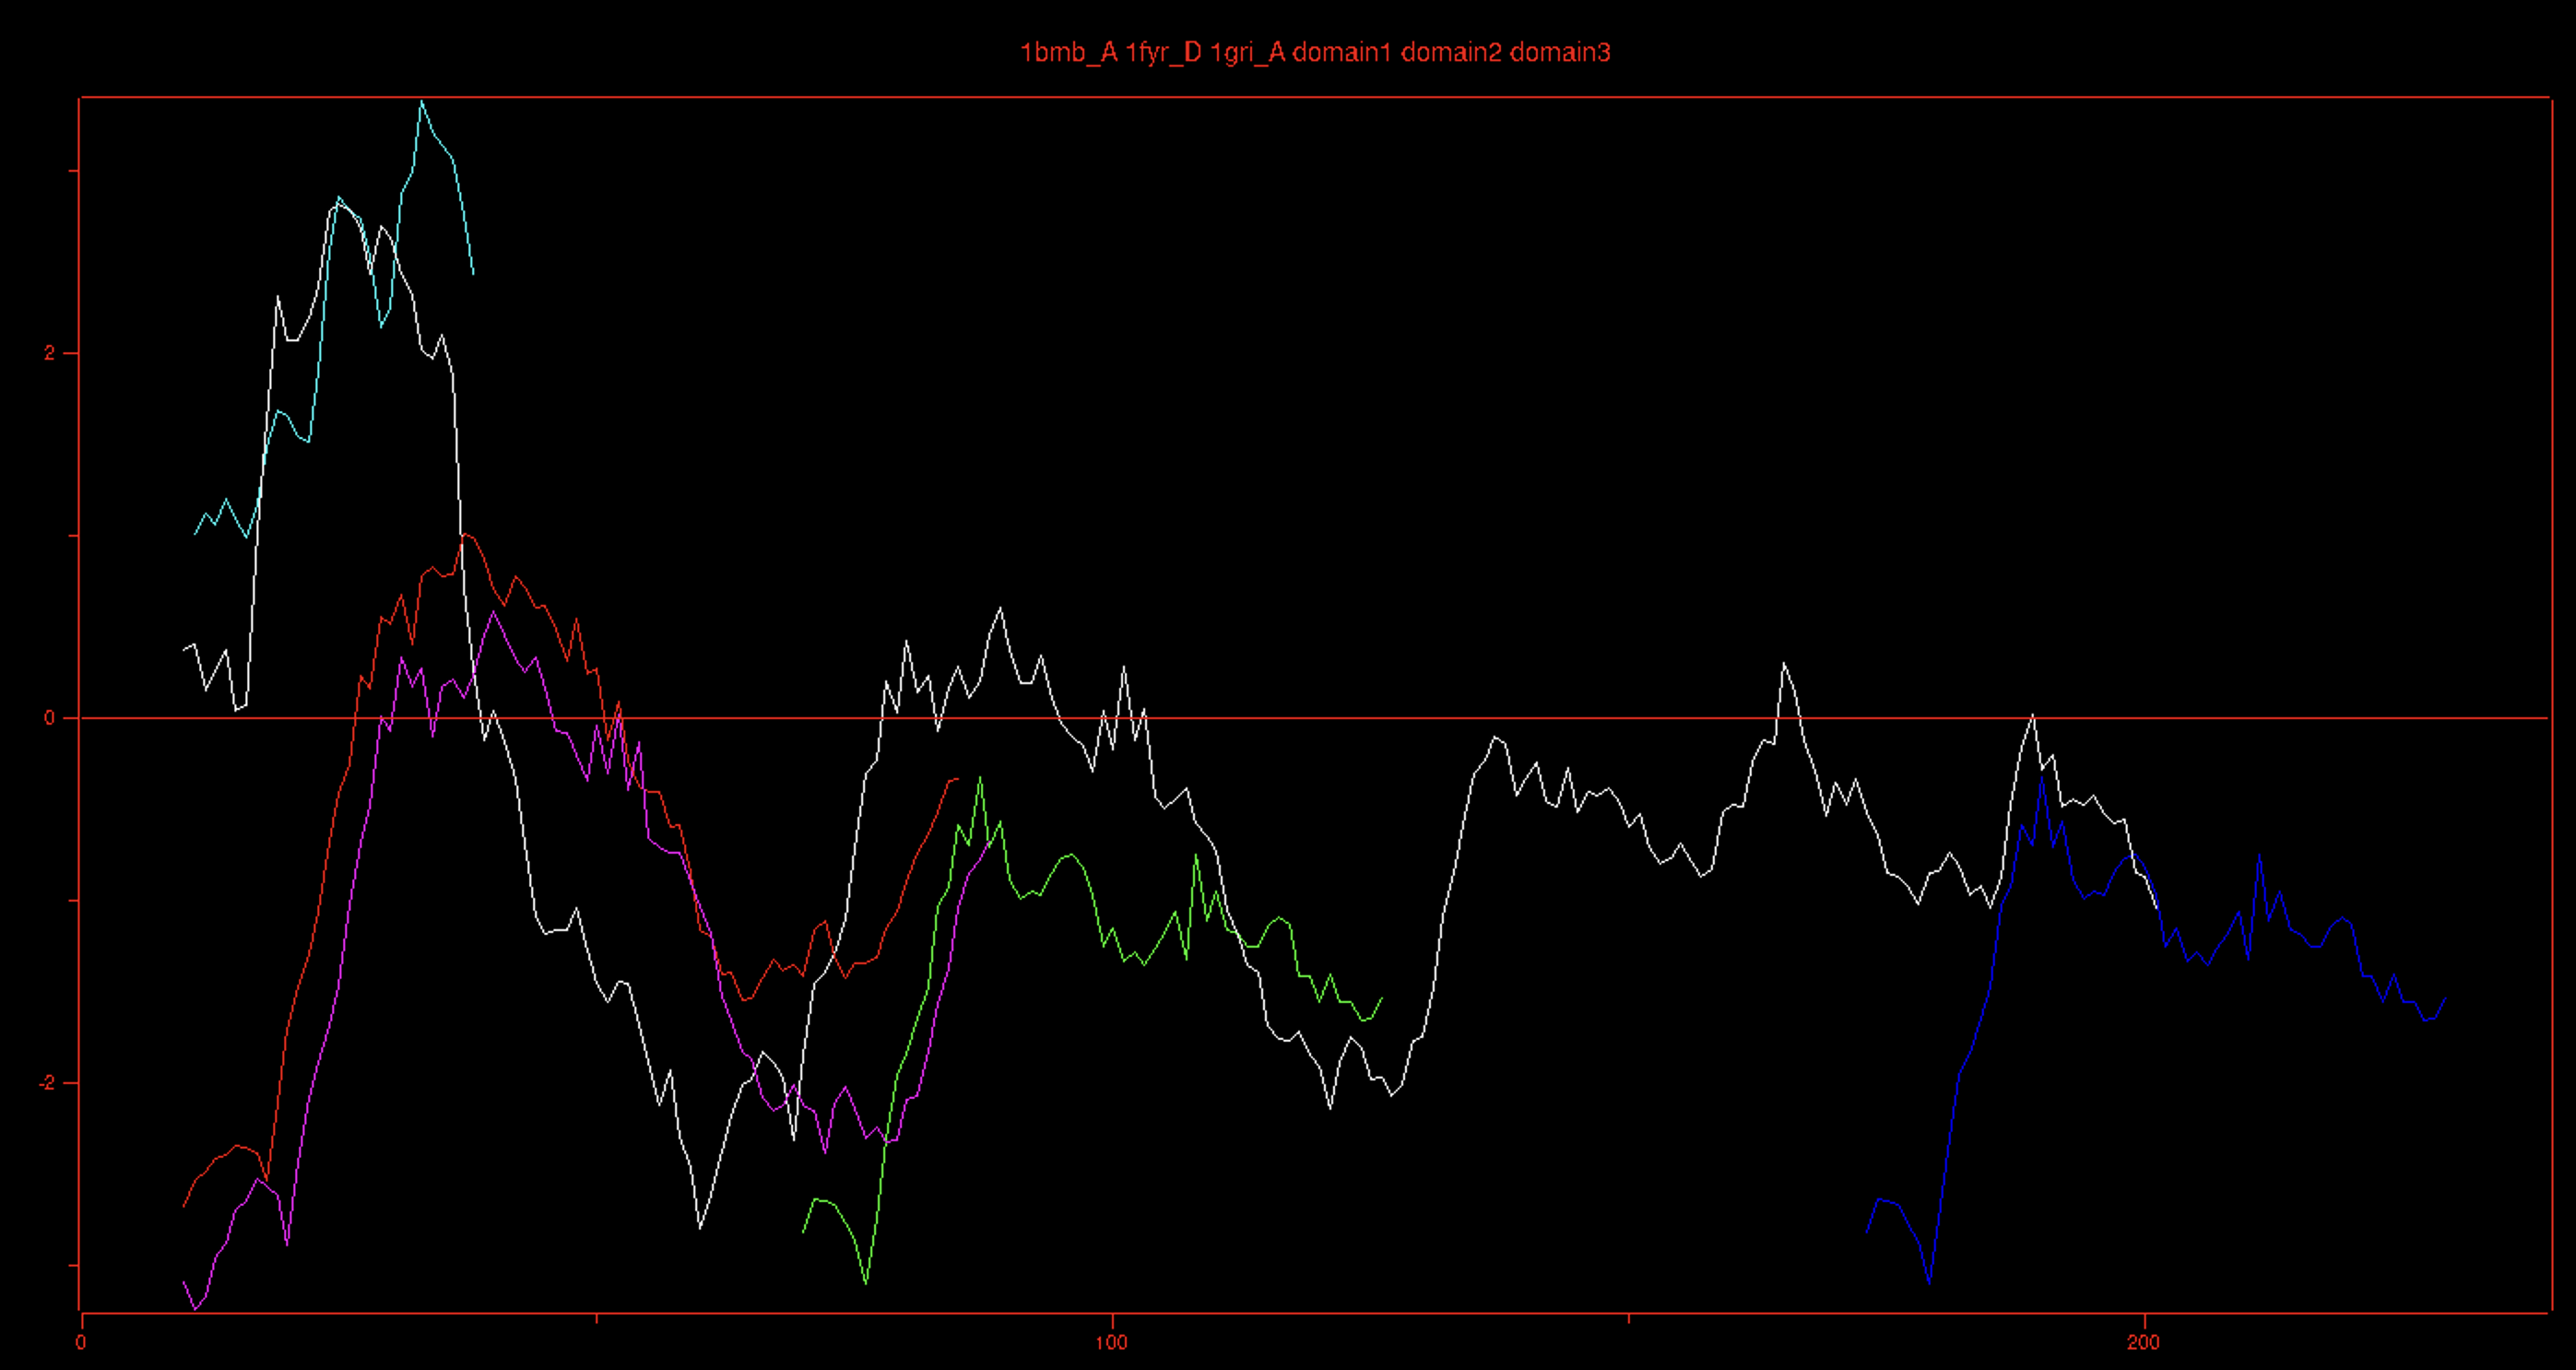

As shown in the image, the only template that shares the three domains is the white one (1gri_A), because as we say earlier, it is the one that has the three different domains. However white, red and magenta haveshare the green profile, which is the SH2 domain that all three templates has. And the blue domain is the SH3 C-t that only the 1gri_A template has. _The coordinates to visualize the domains are the domain cooridnates of that appeared on the hmmscan on the target_
The dom2 (cyan) is still significantly higher than the others, showing high positivie energy. In a structural sense, this usally means there are atomic overlaps (clashes) or that the residues are in a highly "unhappy" environemnt. As the template also shows this behaviour, this might suggest that the domain model could be following a naturally "unstable" or flexible region of the tempalte. 

```
temp1           98   -7.00   -3.70   -5.80       1       2       1   -4.52   -3.71   -4.13  -130.46   -61.16   -26.77    93.35    26.03    26.01   31.99   23.58    9.11
temp2           95   -3.34   -2.62   -1.90      28     102    1013   -4.52   -3.93   -3.85    -7.33   -35.05    11.06    94.78    24.10    28.18   30.57   22.56    8.99
temp3          211   -7.40   -3.27   -7.54       1      18       1   -4.07   -3.99   -4.02  -192.69   -46.45   -45.12   210.19    75.52    41.55   54.47   37.28   11.50
dom1            47   -1.32    2.00   -3.82    2854   29938      37   -4.62   -3.18   -5.87    43.04    42.46     0.11    74.10     8.47    12.51   23.57   17.03    3.25
dom2            76   -6.06   -3.24   -5.11       1      14       1   -4.53   -3.46   -4.47   -88.53   -58.60    -9.33   106.34    17.01    27.84   32.18   23.32    7.27
dom3            76   -6.06   -3.24   -5.11       1      14       1   -4.53   -3.46   -4.47   -88.53   -58.60    -9.33   106.34    17.01    27.84   32.18  
```
Taking a look at the energies, dom1 is poor, because is mostly above zero (_A positive pair energy suggests that the specific amino acid pairs in your model are "unhappy" in their current 3D arrangement—likely due to steric clashes or a sequence-template mismatch. Also this domain has only 47 residues, is very small. ProSA Z-scores are length-dependent, so smaller domains often have "worse" (less negative) scores_). The other ones from dom2 and dom3 are higly stable. Since 1gri_A also appears in that zona above 0, this domain could be naturally more flexible than the other domains. 

__j) Compare with Prosa2003 the energies of the target model with the largest sequence modelled and the original templates. Keep the image of the energy profile as p9j_prosa.jpg.__

Here, shift the focus from the individual domains to the best "Global" model. This is the fnal 3D structure generated that contains the largest possible portion of hte target sequence. Here I am validating the entire protein model at once. Instead of comparing domain1, domain2, etc. I am comparing thmy full-length model (the one with SH3N-t, SH2 and SH3C-t), against the templates simultaneously. 

The model to compare is the `p9h_global.pdb`and the templates to be load are `1bmb_A.pdb`, `1fyr_D.pdb`and `1gri_A.pdb`. Calculate the energy profile for the entire target model. 

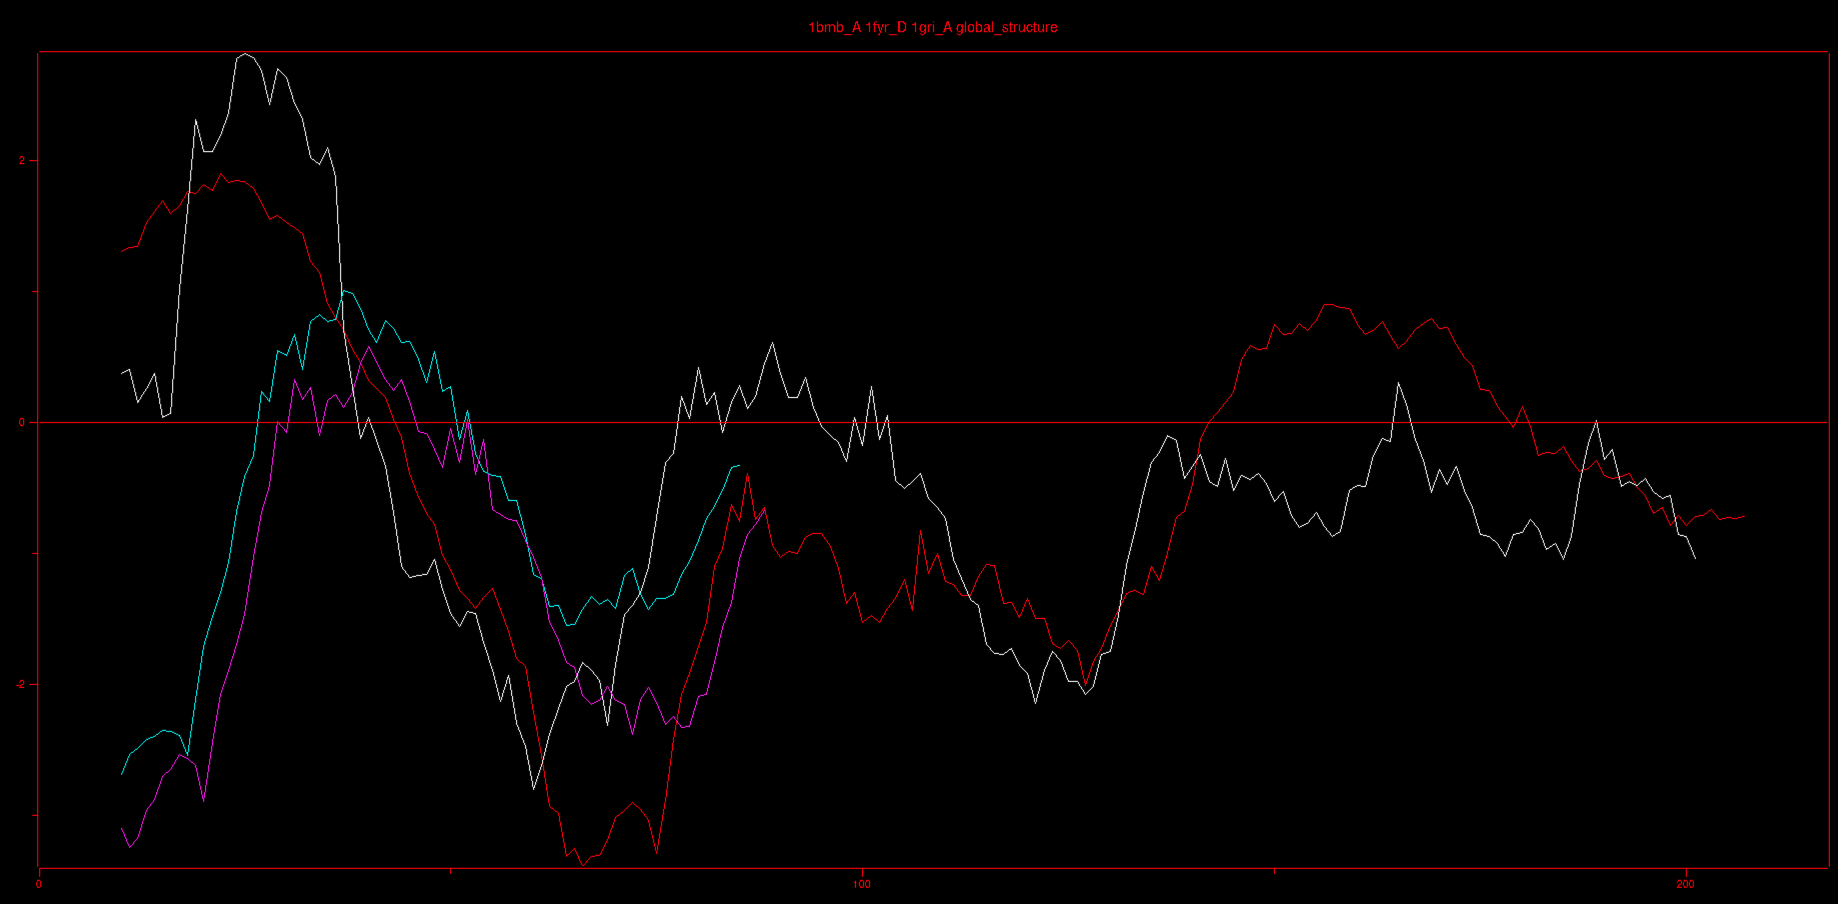
This plot clearly demonstrates how the target sequence "covers" the different structural templates across the entire length. 

The energies are:

```
Hide & Seek on polyprotein pII3.0.short.ply - selection of parameters
molecule     seq-l zp-comb zp-pair zp-surf rk-comb rk-pair rk-surf z1-comb z1-pair z1-surf  ep-comb  ep-pair  ep-surf  em-comb  em-pair  em-surf es-comb es-pair es-surf
temp1           98   -7.00   -3.70   -5.80       1       2       1   -4.52   -3.71   -4.13  -130.46   -61.16   -26.77    93.35    26.03    26.01   31.99   23.58    9.11
temp2           95   -3.34   -2.62   -1.90      28     102    1013   -4.52   -3.93   -3.85    -7.33   -35.05    11.06    94.78    24.10    28.18   30.57   22.56    8.99
temp3          211   -7.40   -3.27   -7.54       1      18       1   -4.07   -3.99   -4.02  -192.69   -46.45   -45.12   210.19    75.52    41.55   54.47   37.28   11.50
global         217   -2.98   -2.97   -1.31      43      52    2928   -3.98   -3.85   -3.95    72.00   -47.45    34.23   252.05    77.44    50.04   60.48   41.99   12.03
```


The target model (in red) is the p9g_global.pdb and most of their structure sits below 0 line, which indicates stable, native-like fold.  The red plot (p9g_global.pdb) follows a simialr behaviours as the white one (1gri_A). We also see that in the lot, at the beggining and end of it, there are above 0 energies and that would be due to th e lack of not enough templates to be comapred, as only 1gri_A had SH3 domains. And the perfect "valley" happens in the SH2 region, where all three templates have it. Also, a score of `-2.98`is a bit weak compared to the template's score. This is very common in himology modeling when have long linkers or loops that weren't in the template. Prosa is penalizing those "unstructured" parts of the global structure. 


#### RESUMEN:

_El análisis de las energías por residuo revela que los dominios dom2 y dom3 presentan una alta estabilidad, con Z-scores de -6.06, comparables a los de los moldes experimentales. Sin embargo, el dom1 (Cian) muestra picos de energía por encima de 0 y un componente de energía de pares (zp-pair) positivo de 2.00. Estos valores indican la presencia de clashes o choques estéricos, donde la proximidad excesiva entre átomos no enlazados genera repulsión y reduce la estabilidad local del modelo. Esto sugiere que el Domain 1 es la región con mayor incertidumbre estructural o menor ajuste al molde utilizado._

__k) Compare the prediction of the secondary structure of the target and the structure of the model built for this target. Keep the alignment with the comparison in a text file and name it p9k_ss.aln__

For the __prediction of the secondary structure__ --> `psipred target.fa`

Will obtain `target.horiz` and `target.ss2` files

To __calculate the secondary structure__ --> `dssp p9h_global.pdb p9k.dssp`

`psipred.pl target.ss2 > psipred.pir`

`aliss_old.pl p9k.dssp > dssp.pir`

```
>P1;p9k.dsspSeq
p9k.dsspSeq 
MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGFIPKNYIRVKPHPWYSGRISRQLAEEILMKRNHL
GAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFLWEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPGA
CFAQAQFDFSAQDPSQLSFRRGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPVHL*
>P1;p9k.dsspSS
p9k.dsspSS 
-------------------STTSS------------------S----------------SEEES--HHHHHHHHHH-SST
TEEEEEE-SSSTT-EEEEEEETTEEEEEE-EE-TT--EESSS--BSSHHHHHHSS-------------------------
-S------------------SS----------S----SS--------------SS--*
>P1;p9k.dsspACC
p9k.dsspACC 
WCCCBCCDCBEBCCCCDBEBEFCDBCBDBDCBDBCCCDECBCWBBDCBBBCDDCCCDCEGGGIFAGFFGAFGFAGDFCEF
FAGAAAHAFCHDDHIAIAHAEFCEAFIHFAGFFWFGGIIAECEFAEHIFHAIEGFDCCDBECWDDECBBCBCBDCBCBWB
CBDBCBBCCDFWCWCBBBCDBDBECCCDBDCGWBDEBDWECCCCWDEDDCCBFWECW*
```
Now I'll concatenate the pir alignment of the dssp and the psipred (the predicted model) into one file and convert it in clustal format!

`cat psipred.pir > compare.pir`

`cat dssp.pir >> compare.pir`

`aconvertMod2.pl -in p -out c < compare.pir > p9k_ss.aln`

```
CLUSTAL W(1.60) multiple sequence alignment

target.ss2Seq  MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGFIPKNYIRVKPHPW
target.ss2SS   CCEEEEEEEECCCCCCCCCCCCCEEEEEECCCCCCEEHHHHHCCCCCCCCCEEEECCCCC
p9k.dsspSeq    MESVALYSFQATESDELAFNKGDTLKILNMEDDQNWYKAELRGVEGFIPKNYIRVKPHPW
p9k.dsspSS     -------------------STTSS------------------S----------------S
p9k.dsspACC    WCCCBCCDCBEBCCCCDBEBEFCDBCBDBDCBDBCCCDECBCWBBDCBBBCDDCCCDCEG

target.ss2Seq  YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
target.ss2SS   CCCHHHHHHHHHHHHHCCCCEEEEEEECCCCCCEEEEEEECCCCEEEEEEEHHHCCCEEC
p9k.dsspSeq    YSGRISRQLAEEILMKRNHLGAFLIRESESSPGEFSVSVNYGDQVQHFKVLREASGKYFL
p9k.dsspSS     EEES--HHHHHHHHHH-SSTTEEEEEE-SSSTT-EEEEEEETTEEEEEE-EE-TT--EES
p9k.dsspACC    GGIFAGFFGAFGFAGDFCEFFAGAAAHAFCHDDHIAIAHAEFCEAFIHFAGFFWFGGIIA

target.ss2Seq  WEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPGACFAQAQFDFSAQDPSQLSFR
target.ss2SS   CHHHCCCHHHHHHHHHHHHHHHHCCEEECCCCCCCCCCCCEEEEEEECCCCCCHHHCCCC
p9k.dsspSeq    WEEKFNSLNELVDFYRTTTIAKKRQIFLRDEEPLLKSPGACFAQAQFDFSAQDPSQLSFR
p9k.dsspSS     SS--BSSHHHHHHSS--------------------------S------------------
p9k.dsspACC    ECEFAEHIFHAIEGFDCCDBECWDDECBBCBCBDCBCBWBCBDBCBBCCDFWCWCBBBCD

target.ss2Seq  RGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPVHL
target.ss2SS   CCCEEEEECCCCCCCCCCCCCCCCCCCCHHHCCCCCC
p9k.dsspSeq    RGDIIEVLERPDPHWWRGRSCGRVGFFPRSYVQPVHL
p9k.dsspSS     SS----------S----SS--------------SS--
p9k.dsspACC    BDBECCCDBDCGWBDEBDWECCCCWDEDDCCBFWECW

```
There's a huge discrpancy with the predicted (ss2SS) with what dssp calculated with my 3D model. In the dssp line, there's a lot of "-" and letters such as `S`or `T`stands for blend or turn respectiverly. This alignment reveals a partial correlatoin between ab initio secondary structure prediction and the final 2D homology model. 
- The _central region_ of the protein (60-120, where SH3 domain is) showsh high conservation of the secondary structure elements, with alpha-helices and beta-strands in the model matching with the predicted states nearly perfect. This are represents the most stable and reliable part of the fold. However, in the N-t and C-t regions, the DSSP aalysis identifies primarly "coils", "turns" or "blends" instead of the predictes strands and helices. __This lack of formal assingment by DSSP suggests that while the residues are in the correct general position, the hydrogen-bonding patterns required for helices and sheets are not fully establishd or distorted in the model. This discrepancies in the secondary structure correlate with the energetic peakcs oversed in the prosa__.